# Nearby Analysis

The nearby analysis centers on understanding what properties are _nearby_, aiming to answer the following:

- Are there vacant properties nearby?
- What is the distribution of acreage size of the nearby?
- How many have tax address outsize of the State?

Best known location:

```text
lon=-79.9513103495131,
lat=32.706641645949055,
```


In [2]:
import pandas as pd
from sqlalchemy import select
import matplotlib.pyplot as plt
import seaborn as sns

from app.config import settings
from app.db import get_session
from app.models import Parcel, NearbyParcelIdsParams
from app.nearby_parcel_request import fetch_nearby_ids, fetch_pids

pd.set_option("display.max_columns", None)

params = NearbyParcelIdsParams(
    lon=-79.9513103495131,
    lat=32.706641645949055,
    distance=5.0,
)

nearby_objectids_response = fetch_nearby_ids(params)

assert nearby_objectids_response is not None

nearby_pids = fetch_pids(nearby_objectids_response.objectIds)
len(nearby_pids), nearby_pids[:10]

(25796,
 ['4281100063',
  '3150000515',
  '3340500042',
  '4570803115',
  '4261600134',
  '4211100262',
  '4571602005',
  '4260700126',
  '3150000348',
  '3400300087'])

In [3]:
session = next(get_session())

stmt = select(Parcel).where(
    Parcel.pid.in_(nearby_pids)
)

nearby_df = pd.read_sql_query(stmt, con=session.bind)
nearby_over_1 = nearby_df[nearby_df["acreage"] > 1.0]
nearby_over_1.shape
nearby_df.shape

(25792, 27)

In [42]:
nearby_df["acreage"].eq(0).mean()

np.float64(0.6688508064516129)

In [43]:
nearby_df["acreage"].describe()

count    25788.000000
mean         1.037624
std         25.239285
min          0.000000
25%          0.000000
50%          0.000000
75%          0.170000
max       2745.000000
Name: acreage, dtype: float64

In [44]:
nearby_df["acreage"].value_counts().head(20)

acreage
0.00    17251
0.21      333
0.24      259
0.23      225
0.06      218
0.22      202
0.14      197
0.15      183
0.25      181
0.09      180
0.20      177
0.16      176
0.18      175
0.17      166
0.19      164
0.08      160
0.29      144
0.26      129
0.34      127
0.10      123
Name: count, dtype: int64

The classes with good acreage coverage are even more revealing:

800 - AGRICULTURAL      1% zero
900 - RES-DEV-ACRS      3% zero
910 - COM-DEV-ACRS      0% zero
730 - GOLF COURSE       0% zero

Those are all parcel types where acreage is fundamentally important to assessment.

An agricultural parcel without acreage would be difficult to value.

A development tract without acreage would be difficult to value.

A golf course without acreage would be difficult to value.

The assessor appears to care about acreage only when acreage materially affects taxation.

In [45]:
(
    nearby_df.groupby("class_code")["acreage"]
    .apply(lambda s: (s == 0).mean())
    .sort_values(ascending=False)
)

class_code
300 - BUILDNG-ONLY                1.000000
225 - SPCLTY-CNU-TMSBRG           1.000000
250 - SPCLTY-COMMCONDO            1.000000
160 - RESID-CNU                   0.996115
750 - SPCLTY-REC                  0.977401
999 - Not Currently Classified    0.937500
460 - AUTO-PARKING                0.892473
210 - SPCLTY-SMA                  0.867925
170 - RESID-ROW                   0.842105
130 - RESID-DUP/TRI               0.833819
165 - CONDO COMMON                0.750000
167 - CONDO COMMON COMM           0.720000
101 - RESID-SFR                   0.679840
121 - GROUP-LIV                   0.600000
471 - TELEPH-COMM                 0.500000
711 - MUSEUM-CULT                 0.461538
990 - UNDEVELOPABLE               0.447077
120 - RESID-TWH                   0.441503
195 - COMM-APP-RES                0.428571
500 - General Commercial          0.415789
481 -  PUBLIC-UTIL                0.400000
700 - SPCLTY-HTL                  0.357143
624 - CEMETERIES                  0.333333


In [46]:
nearby_df.groupby(
    pd.cut(
        nearby_df["acreage"],
        bins=[-0.01, 0, 0.25, 0.5, 1, 5, 10, 100, 5000]
    )
).size()

acreage
(-0.01, 0.0]       17251
(0.0, 0.25]         3835
(0.25, 0.5]         1959
(0.5, 1.0]          1129
(1.0, 5.0]          1160
(5.0, 10.0]          202
(10.0, 100.0]        213
(100.0, 5000.0]       39
dtype: int64

In [4]:
nearby_over_1["class_code"].value_counts().sort_index()

class_code
101 - RESID-SFR             623
110 - RESID-MBH              21
121 - GROUP-LIV               2
130 - RESID-DUP/TRI           1
160 - RESID-CNU               6
165 - CONDO COMMON           23
167 - CONDO COMMON COMM       2
200 - SPCLTY-APT             16
210 - SPCLTY-SMA              2
304 - MFG/INDUST              1
411 - RAILRD/TRAIN            4
451 - ROAD-ROW                6
460 - AUTO-PARKING            1
481 -  PUBLIC-UTIL            2
500 - General Commercial     76
530 - SPCLTY-RTL             18
580 - SPCLTY-RST              4
624 - CEMETERIES              2
630 - SPCLTY-WHS             14
650 - SPCLTY-OFC              3
671 - GOVT-BLDG              12
681 - SCHOOLS                15
691 - RELIGIOUS              33
700 - SPCLTY-HTL              5
711 - MUSEUM-CULT             4
730 - GOLF COURSE             2
742 - HOA-PROP               43
750 - SPCLTY-REC              4
800 - AGRICULTURAL           88
900 - RES-DEV-ACRS           28
905 - VAC-RES-LOT           3

| Class Code          | Count | Meaning                             |
| ------------------- | ----- | ----------------------------------- |
| 905 - VAC-RES-LOT   | 1,770 | Vacant residential lot              |
| 952 - VAC-COMM-LOT  | 121   | Vacant commercial lot               |
| 900 - RES-DEV-ACRS  | 32    | Residential development acreage     |
| 910 - COM-DEV-ACRS  | 1     | Commercial development acreage      |
| 990 - UNDEVELOPABLE | 633   | Marsh, wetlands, ROW remnants, etc. |



| Code | Description | Category |
| :--- | :--- | :--- |
| **101** | RESID-SFR (Single Family Residence) | Residential |
| **110** | RESID-MBH (Mobile Home) | Residential |
| **120** | RESID-TWH (Townhouse) | Residential |
| **130** | RESID-DUP/TRI (Duplex / Triplex) | Residential |
| **140** | MH-PARKS (Mobile Home Parks) | Residential |
| **165** | CONDO COMMON | Residential |
| **167** | CONDO COMMON COMM | Residential |
| **195** | COMM-APP-RES (Mixed Use Commercial/Res) | Residential |
| **200** | SPCLTY-APT (Specialty Apartment) | Residential |
| **220** | SPCLTY-TAMSBERG | Residential |
| **250** | SPCLTY-COMMCONDO (Commercial Condo) | Commercial |
| **300** | BUILDNG-ONLY | Commercial |
| **304** | MFG/INDUST (Manufacturing / Industrial) | Commercial |
| **411** | RAILRD/TRAIN (Railroad Tracks) | Infrastructure |
| **451** | ROAD-ROW (Road Right-of-Way) | Infrastructure |
| **460** | AUTO-PARKING | Infrastructure |
| **471** | TELEPH-COMM (Telephone / Cell Towers) | Infrastructure |
| **481** | PUBLIC-UTIL (Public Utilities) | Infrastructure |
| **500** | General Commercial | Commercial |
| **530** | SPCLTY-RTL (Specialty Retail) | Commercial |
| **580** | SPCLTY-RST (Specialty Restaurant) | Commercial |
| **624** | CEMETERIES | Civic / Institutional |
| **630** | SPCLTY-WHS (Specialty Warehouse) | Commercial |
| **650** | SPCLTY-OFC (Specialty Office) | Commercial |
| **671** | GOVT-BLDG (Government Building) | Civic / Institutional |
| **681** | SCHOOLS | Civic / Institutional |
| **691** | RELIGIOUS (Churches / Temples) | Civic / Institutional |
| **700** | SPCLTY-HTL (Specialty Hotel) | Commercial |
| **711** | MUSEUM-CULT (Museums) | Civic / Institutional |
| **730** | GOLF COURSE | Infrastructure |
| **742** | HOA-PROP (Homeowners Association) | Infrastructure |
| **750** | SPCLTY-REC (Specialty Recreation) | Infrastructure |
| **800** | AGRICULTURAL | Vacant / Ag |
| **900** | RES-DEV-ACRS (Residential Development) | Vacant / Ag |
| **905** | VAC-RES-LOT (Vacant Residential Lot) | Vacant / Ag |
| **910** | COM-DEV-ACRS (Commercial Development) | Vacant / Ag |
| **952** | VAC-COMM-LOT (Vacant Commercial Lot) | Vacant / Ag |
| **990** | UNDEVELOPABLE | Vacant / Ag |



In [8]:
nearby_vacant = nearby_df[
    nearby_df["class_code"].isin([
        "900 - RES-DEV-ACRS",
        "905 - VAC-RES-LOT",
        "910 - COM-DEV-ACRS",
        "952 - VAC-COMM-LOT",
    ])
]
nearby_vacant.shape

(1932, 27)

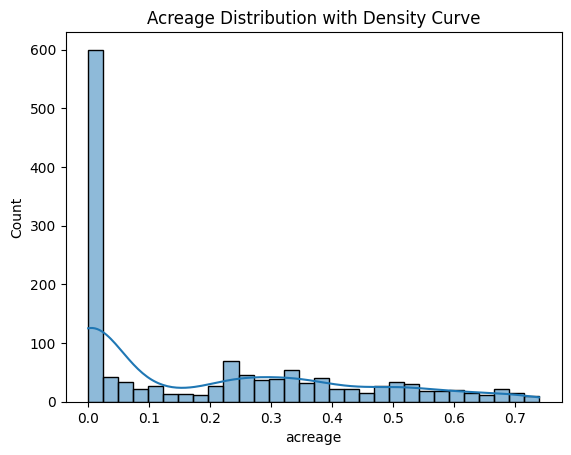

In [15]:
sns.histplot(data=nearby_vacant[nearby_vacant["acreage"] < 0.75], x="acreage", bins=30, kde=True)
plt.title("Acreage Distribution with Density Curve")
plt.show()

In [29]:
nearby_vacant[nearby_vacant["acreage"] == 0]["class_code"].value_counts()

class_code
905 - VAC-RES-LOT     568
952 - VAC-COMM-LOT     30
900 - RES-DEV-ACRS      1
Name: count, dtype: int64

In [40]:
nearby_vacant[nearby_vacant["acreage"] == 0]["tax_district"].value_counts()

tax_district
3-1    174
3-4    137
3-8    117
3-3     97
3-5     30
7-1     30
5-1      7
6-3      6
3-6      1
Name: count, dtype: int64

In [37]:
nearby_vacant[nearby_vacant["acreage"] == 0]["subdivision"].value_counts(dropna=False)

subdivision
NaN                           578
CREEKSIDE HPR                  10
115 E ARCTIC AVENUE HPR         6
206 WEST ARCTIC/ASHLEY HPR      2
OAK ISLAND                      1
JAMES ISLAN                     1
206 EAST ARCTIC/ASHLEY HPR      1
Name: count, dtype: int64

In [11]:
nearby_vacant_between_1_and_10 = nearby_vacant.query("acreage >= 1.0 and acreage <= 10.0")
len(nearby_vacant_between_1_and_10)

396

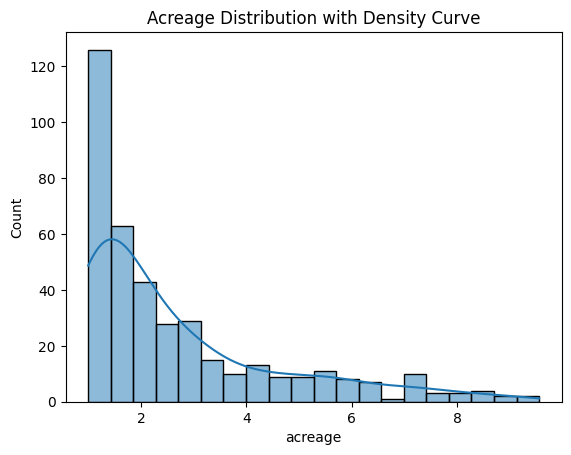

In [12]:
sns.histplot(data=nearby_vacant_between_1_and_10, x="acreage", bins=20, kde=True)
plt.title("Acreage Distribution with Density Curve")
plt.show()

In [13]:
nearby_vacant_between_1_and_10["acreage"].quantile(0.80)

np.float64(4.0)

In [14]:
nearby_vacant_between_1_and_10["mail_state"].value_counts()

mail_state
SC    334
GA     10
NC     10
NY      8
MD      7
NJ      4
CA      4
VA      4
FL      3
PA      2
CO      2
OH      1
MI      1
TX      1
DC      1
AL      1
CT      1
MA      1
NV      1
Name: count, dtype: int64

In [15]:
(
    nearby_vacant_between_1_and_10
        .query("mail_state != 'SC'")
        .sort_values(by="acreage")
        .drop(columns=["subdivision", "objectid", "mail_country", "other", "doc_date"])
        .filter(regex=r"^(?!.*2nd)")
        .head(50)
)

,pid,snapshot_at,owner1,owner2,tax_district,class_code,mail_st_no,mail_st_name,mail_st_type,mail_city,mail_state,mail_zip,legal_descr,acreage,legal_residence,agr,deed_book_page,plat_book_page,sale_price,recorded_date
1629,3340500059,2026-06-19 19:23:10.606020,RICHARDSON HENRY ESTATE,ETAL,3-1,905 - VAC-RES-LOT,141,PHELPS,AVE,ENGLEWOOD,NJ,07631,TRACT B LIBERTY HILL,1.00,N,N,Y119-266,AP-131,0.0,1979-08-02
17228,4280800017,2026-06-19 19:23:10.606020,BROWN EVELYN,NaN,3-8,905 - VAC-RES-LOT,2825,GARFIELD,LN,TREVOSE,PA,19053-6720,TR SW PT D 2 ROYAL,1.00,N,N,O148-444,Z51-451,29950.0,1985-10-02
13886,3180000549,2026-06-19 19:23:10.606020,CHENEY BURKE,CHENEY ANN,5-1,905 - VAC-RES-LOT,11,CLIFFVIEW,DR,NORWALK,CT,06850,Lot 1,1.03,N,N,1088-203,L21- 0448,40000.0,2022-03-11
500,4520600126,2026-06-19 19:23:10.606020,DE GRAAF GLENN LIVING TRUST,DE GRAAF MELISSA H LIVING TRUST,3-5,905 - VAC-RES-LOT,62,CONIFER,CIR,AUGUSTA,GA,30909,LOT 19,1.04,N,N,1289-320,EH-603,975000.0,2025-01-13
15994,3301000076,2026-06-19 19:23:10.606020,MCCAIN JAMES THOMAS,NaN,3-1,905 - VAC-RES-LOT,NaN,3875 UNION ROAD SW,NaN,ATLANTA,GA,30349,LOT 9,1.04,N,N,1296-142,EA-207,5.0,2025-02-24
21792,4280600002,2026-06-19 19:23:10.606020,GIBSON LUKE AND BREEANNA FAMILY TRUST,NaN,3-8,905 - VAC-RES-LOT,13465,CAMINO CANADA,NaN,EL CAJON,CA,92021,LT 2B,1.05,N,N,1280-586,J-80,0.0,2024-11-21
16068,4391300080,2026-06-19 19:23:10.606020,FOLLY PROPERTIES LLC,NaN,3-3,905 - VAC-RES-LOT,NaN,NaN,NaN,JONESVILLE,VA,24263-0662,LT 1210,1.09,N,N,0512-035,T-155,800000.0,2015-10-20
7240,3400000028,2026-06-19 19:23:10.606020,HAMILTON NAT,POLLY,3-1,905 - VAC-RES-LOT,430,M,ST,WASHINGTON,DC,20024,LOT C,1.10,N,N,Y024-227,MC13-44,0.0,1908-01-01
16274,3400000058,2026-06-19 19:23:10.606020,BOONE RUBEA ANGENITA W,SMALL LOURDES A,3-5,905 - VAC-RES-LOT,1902,THREE MEADOWS ROAD,NaN,GREENSBORO,NC,27455,LOT 3,1.10,N,N,1286-217,BC-54,0.0,2024-12-23
2523,4520500091,2026-06-19 19:23:10.606020,BANKS MCRAE C II,BANKS LUCY H,3-8,905 - VAC-RES-LOT,2701,LUNSFORD RD,NaN,SUMMERFIELD,NC,27358,LOT 1A,1.13,N,N,1317-845,AS-20,140000.0,2025-06-09


In [17]:
nearby_df.query("class_code == '800 - AGRICULTURAL' and acreage > 1.0").sort_values(by="acreage")

,pid,objectid,snapshot_at,owner1,owner2,tax_district,class_code,mail_st_no,mail_st_name,mail_st_type,mail_2nd_addr,mail_2nd_addt,mail_city,mail_state,mail_zip,mail_country,legal_descr,subdivision,acreage,legal_residence,other,agr,deed_book_page,plat_book_page,sale_price,recorded_date,doc_date
4806,3410000077,36874,2026-06-19 19:23:10.606020,MAMIESAN LLC,NaN,3-1,800 - AGRICULTURAL,1597,NaN,NaN,NaN,NaN,KENNESAW,GA,30156,NaN,PARCEL C,NaN,1.04,N,N,Y,0769-394,CC-43,1000.0,2018-12-31,2018-12-28
5368,3210000013,41063,2026-06-19 19:23:10.606020,VILLAGE PLACE PROPERTIES LLC,NaN,5-1,800 - AGRICULTURAL,30004,NaN,NaN,NaN,NaN,CHARLESTON,SC,29417-0004,NaN,NaN,NaN,1.10,N,N,Y,C661-371,C-12,290000.0,2008-06-02,2008-06-02
10112,4520500058,77289,2026-06-19 19:23:10.606020,MORAWITZ LAURA C,SUGARBERRY JUMP LLC,3-8,800 - AGRICULTURAL,5347,NaN,NaN,NaN,NaN,KETCHUM,ID,83340,NaN,NaN,NaN,1.30,N,N,Y,0300-327,Q64-343,10.0,2012-12-28,2012-12-24
2744,3150000003,21339,2026-06-19 19:23:10.606020,MOSELEY LIVING TRUST,NaN,5-1,800 - AGRICULTURAL,2604,EXCHANGE LANDING,RD,NaN,NaN,JOHNS ISLAND,SC,29455,NaN,LT 3,NaN,1.51,N,N,Y,1123-035,G-71,10.0,2022-07-11,2022-06-16
7229,3150000002,54805,2026-06-19 19:23:10.606020,MOSELEY LIVING TRUST,NaN,5-1,800 - AGRICULTURAL,2604,EXCHANGE LANDING,RD,NaN,NaN,JOHNS ISLAND,SC,29455,NaN,LT 2,NaN,1.53,N,N,Y,1123-035,G-71,10.0,2022-07-11,2022-06-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13934,3370000001,106022,2026-06-19 19:23:10.606020,CHARLESTON MUSEUM THE,NaN,3-4,800 - AGRICULTURAL,360,MEETING,ST,NaN,NaN,CHARLESTON,SC,29403-6235,NaN,TRACT B,NaN,297.06,N,N,N,F170-287,J-90,0.0,1987-11-04,1987-11-04
20483,4500000003,156701,2026-06-19 19:23:10.606020,COLES ISLAND-BUERO FAMILY CORPORATION,NaN,3-1,800 - AGRICULTURAL,1422,RIVE FRONT DR,NaN,NaN,NaN,CHARLESTON,SC,29407,NaN,NaN,NaN,303.00,N,N,Y,1128-947,C-159,5.0,2022-08-04,2022-08-02
18913,4500000025,144780,2026-06-19 19:23:10.606020,CRAIGIE JAMES E,NaN,3-1,800 - AGRICULTURAL,885,ROBERT E LEE,BLVD,NaN,NaN,CHARLESTON,SC,29412,NaN,TRACT C,NaN,326.85,N,N,Y,H615-161,EA-145,775000.0,2008-02-15,2008-02-14
17545,3290000006,134451,2026-06-19 19:23:10.606020,HORLBECK JOHN WILCOX,ETAL,3-1,800 - AGRICULTURAL,821,CAPTAIN TOMS CROSSING,NaN,NaN,NaN,JOHNS ISLAND,SC,29455,NaN,NaN,NaN,406.50,N,N,Y,E186-575,K-135,1.0,1989-07-25,1989-06-21


In [22]:
vacant_over_1["subdivision"].value_counts().sort_index()

subdivision
BAYVIEW FARMS                        2
BLACKLOCK PLANTATION                 1
CENTERVILLE                          1
CENTRAL PARK CLUSTER DEVELOPMENT     1
CHARLESTO                            1
CHARLESTON                          10
CHARLESTON COUNTY                    1
CITY OF CHARLESTO                    1
CITY OF CHARLESTON                  12
CROSS CREEK TOWNHOMES                1
DIVISION 3 BLACKLOCK PLANTATIO       1
EXCHANGE PLANTATION                  2
FOLLY BEACH                          4
FOLLY WEST ESTATES                   1
HARBORWALK                           1
JAMES ISLAN                          9
JAMES ISLAND                        25
JENKINS FARM                         3
JOHNS ISLAN                          3
JOHNS ISLAND                        13
LAWTON BLUFF                         1
LIGHTHOUSE POINT                     1
MCINTYRE                             1
MILLER HILL                          1
MORRIS ISLAN                         1
OSWALD       

In [25]:
vacant_over_1[vacant_over_1["subdivision"] == "CITY OF CHARLESTON"]

,id,objectid,pid,owner1,owner2,tax_district,class_code,mail_st_no,mail_st_name,mail_st_type,...,subdivision,acreage,legal_residence,other,agr,deed_book_page,plat_book_page,sale_price,recorded_date,doc_date
269,2076,2076,3340500090,BATTERY ISLAND COMMUNITY LLC,NaN,3-5,905 - VAC-RES-LOT,382,RACE,ST,...,CITY OF CHARLESTON,1.04,N,N,N,-,P25- 0423,0.0,1900-01-01,1900-01-01
4728,36098,36098,4540700122,LENNAR CAROLINAS LLC,NaN,3-5,905 - VAC-RES-LOT,1505,KING ST EXT,NaN,...,CITY OF CHARLESTON,1.05,N,N,N,1341-696,L24- 0407,1960000.0,2025-10-02,2025-09-23
5517,41751,41751,3170000241,RUZHANSKY LLC,NaN,5-2,905 - VAC-RES-LOT,362,ELLIOT,PLACE,...,CITY OF CHARLESTON,2.97,N,N,N,1000-601,S13- 0002,259000.0,2021-06-09,2021-06-07
5999,45207,45207,3150000554,STJF LLC,NaN,5-2,905 - VAC-RES-LOT,2009,TERRABROCK,LN,...,CITY OF CHARLESTON,1.20,N,N,N,-,L23- 0308,0.0,1900-01-01,1900-01-01
7454,56330,56330,3180000555,GRATZICK BENJAMIN ELLIOT,NaN,5-2,905 - VAC-RES-LOT,2485,OAK ROYAL,DR,...,CITY OF CHARLESTON,1.50,N,N,N,1280-791,L24- 0398,5.0,2024-11-22,2024-11-14
7615,57464,57464,3450000213,SOUTH CAROLINA DEPARTMENT OF TRANSPORTATION,NaN,5-2,910 - COM-DEV-ACRS,191,NaN,NaN,...,CITY OF CHARLESTON,11.24,N,N,N,-,S16- 0234-235,0.0,1900-01-01,1900-01-01
8461,63898,63898,3430700055,CITY OF CHARLESTON,NaN,3-5,905 - VAC-RES-LOT,304,NaN,NaN,...,CITY OF CHARLESTON,3.65,N,N,N,1055-472,L24- 0221,425000.0,2021-11-24,2021-11-22
11906,90519,90519,3450000115,SOUTH CAROLINA DEPARTMENT OF TRANSPORTATION,NaN,5-2,900 - RES-DEV-ACRS,191,NaN,NaN,...,CITY OF CHARLESTON,32.40,N,N,N,0546-379,S16- 0234-235,7075000.0,2016-04-11,2016-03-23
15602,119823,119823,3450000214,SOUTH CAROLINA DEPARTMENT OF TRANSPORTATION,NaN,5-2,900 - RES-DEV-ACRS,191,NaN,NaN,...,CITY OF CHARLESTON,29.69,N,N,N,-,S16- 0234-235,0.0,1900-01-01,1900-01-01
16023,123035,123035,3460000559,STONO RIVER INVESTORS LLC,NaN,5-2,952 - VAC-COMM-LOT,49,IMMIGRATION,ST,...,CITY OF CHARLESTON,2.46,N,N,N,1059-698,L24- 0026,2392500.0,2021-12-10,2021-12-09


In [27]:
vacant_over_1.to_excel('vacant_lots_over_1_acre_within_5_miles.xlsx')